<a href="https://colab.research.google.com/github/anishchapagain/Deep-Learning/blob/main/Predict_Insurance_BinClass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Example: Logistic Regression for Binary Classification
### To be compared using Linear Regression TODO

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
np.random.seed(42)

## Some random values

In [4]:
# Generate random ages between 18 and 70
ages = np.random.randint(18, 71, size=200)

# Generate target variable (Bought_Insurance) with higher probability for older ages
bought_insurance = np.array([1 if age > np.random.randint(25, 60) else 0 for age in ages])

In [5]:
df = pd.DataFrame({'Age': ages, 'Bought_Insurance': bought_insurance})

In [6]:
df.head()

,Age,Bought_Insurance
0,56,1
1,69,1
2,46,1
3,32,0
4,60,1


In [7]:
df.describe()

,Age,Bought_Insurance
count,200.000000,200.000000
mean,44.010000,0.500000
std,15.226593,0.501255
min,18.000000,0.000000
25%,31.000000,0.000000
50%,44.000000,0.500000
75%,57.000000,1.000000
max,70.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               200 non-null    int64
 1   Bought_Insurance  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [16]:
df.shape

(200, 2)

In [17]:
df.isnull().sum()

,0
Age,0
Bought_Insurance,0


In [18]:
df['Bought_Insurance'].unique() # Yes or No

array([1, 0])

In [27]:
counts = df[df['Age']>45].value_counts().sort_values(ascending=False)  # check the sums
counts

,,count
Age,Bought_Insurance,
61,1,9
56,1,7
52,1,6
70,1,5
59,1,5
64,1,5
62,1,5
68,1,5
53,1,4


<Axes: xlabel='Age'>

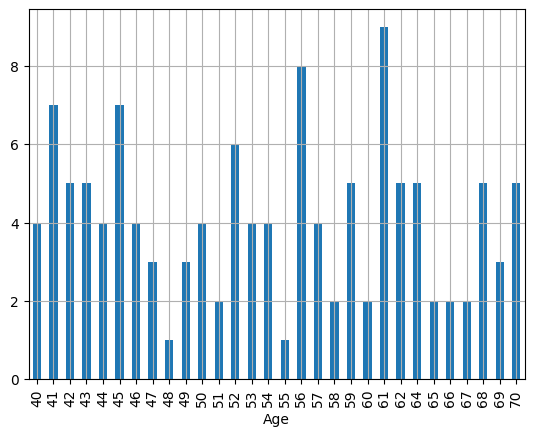

In [34]:
df[df['Age']>39]['Age'].value_counts().sort_index().plot(kind='bar',grid=True) # plotting the Age and counts their counts

## Plots

In [9]:
from matplotlib import pyplot as plt

In [10]:
%matplotlib inline

<Axes: >

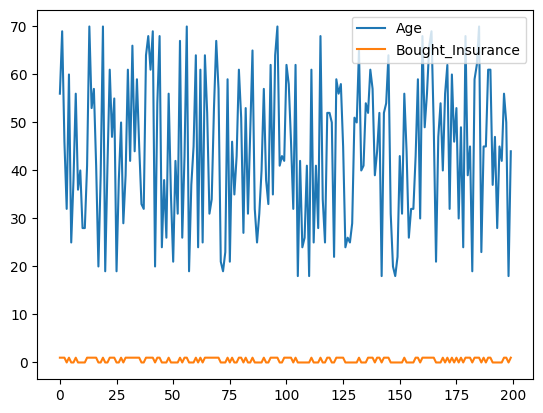

In [11]:
df.plot()

<Axes: xlabel='Age'>

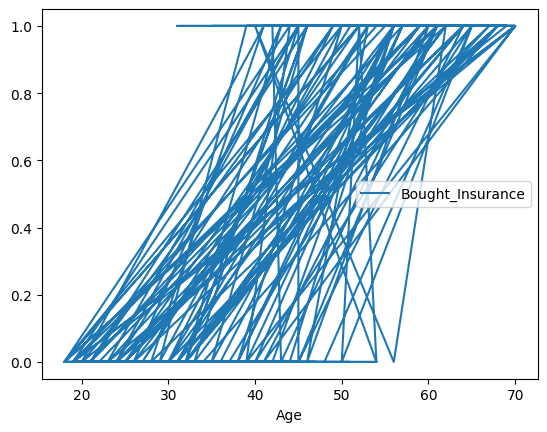

In [14]:
df.plot(kind='line', x='Age', y='Bought_Insurance') # Carefull here!

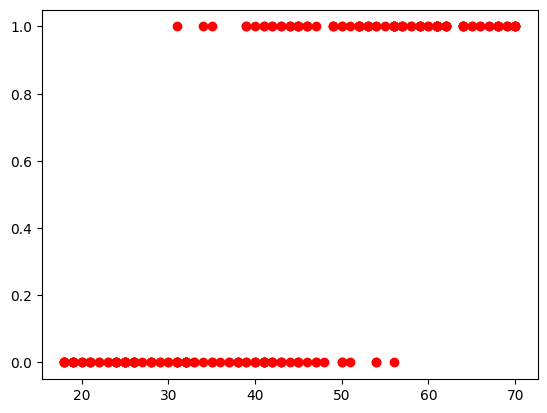

In [12]:
plt.scatter(df['Age'], df['Bought_Insurance'], c='red') # Will linear regression be effective here?

(array([21., 21., 19., 12., 25., 22., 20., 20., 21., 19.]),
 array([18. , 23.2, 28.4, 33.6, 38.8, 44. , 49.2, 54.4, 59.6, 64.8, 70. ]),
 <BarContainer object of 10 artists>)

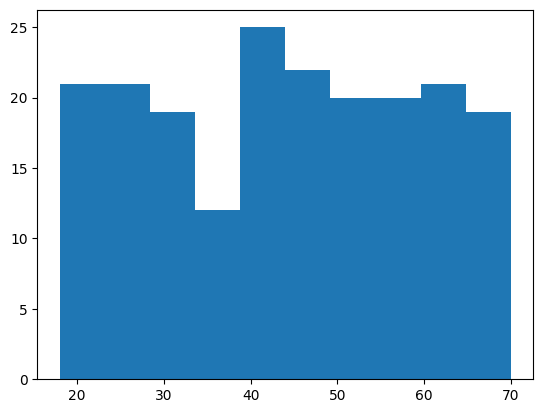

In [13]:
plt.hist(df['Age'])

## Using sklearn

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(df[['Age']], df['Bought_Insurance'], test_size=0.2, random_state=42)

In [37]:
X_train.shape, X_test.shape

((160, 1), (40, 1))

In [39]:
X_test.head()

,Age
95,64
15,57
30,61
158,59
128,25


In [40]:
X_train.head()

,Age
79,61
197,50
38,64
24,55
122,59


## Apply Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

In [45]:
model = LogisticRegression() # Create a Model

In [46]:
model

LogisticRegression()

In [48]:
model.fit(X_train, y_train) # Train the model

LogisticRegression()

In [63]:
model.score(X_test, y_test)

0.8

In [49]:
model.predict(X_test) # Predict the model

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [50]:
X_test.head(10)

,Age
95,64
15,57
30,61
158,59
128,25
115,68
69,67
170,56
174,46
45,24


In [51]:
model.predict(X_test.head(10))

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

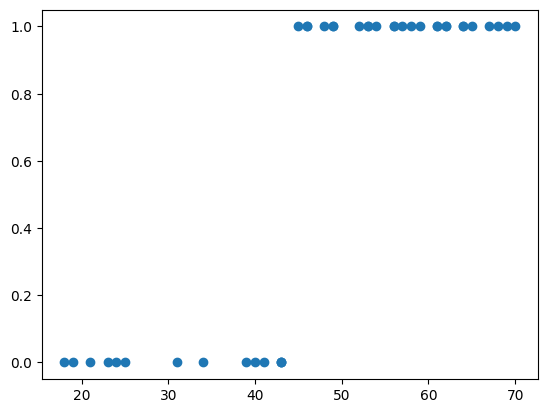

In [52]:
plt.scatter(X_test['Age'], model.predict(X_test))

In [53]:
model.score(X_test, y_test) # Accuracy of the model

0.8

In [54]:
model.predict_proba(X_test.head(10)) # Predict the probability for 10 test values.

array([[0.00574456, 0.99425544],
       [0.03505475, 0.96494525],
       [0.01254538, 0.98745462],
       [0.02103168, 0.97896832],
       [0.99387835, 0.00612165],
       [0.00201653, 0.99798347],
       [0.00262066, 0.99737934],
       [0.04510941, 0.95489059],
       [0.39509117, 0.60490883],
       [0.99528574, 0.00471426]])

## Reports

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score

In [60]:
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71        14
           1       0.85      0.85      0.85        26

    accuracy                           0.80        40
   macro avg       0.78      0.78      0.78        40
weighted avg       0.80      0.80      0.80        40



In [61]:
confusion_matrix(y_test, model.predict(X_test))

array([[10,  4],
       [ 4, 22]])

In [64]:
roc_curve(y_test, model.predict(X_test))

(array([0.        , 0.28571429, 1.        ]),
 array([0.        , 0.84615385, 1.        ]),
 array([inf,  1.,  0.]))

In [68]:
#TODO: model.predict([34,56])  # is throwing error 'X does not have valid feature names, but LogisticRegression was fitted with feature names

model.predict(pd.DataFrame({'Age': [34, 56]})) # 34 is denied, 56 is assumed to take insurance

array([0, 1])

## TODO
### Linear Regression:
  - model = LinearRegression()
### MSE and R2 score